# Actividad Evaluable: Patrones con K-means

Para determinar patrones con K-means comenzamos importando las librerias necesarias y cargando los datos...

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns

df = pd.read_csv("Facebook_Marketplace_data.csv")

Y mostramos la información del dataframe leído y mostramos así como algunas filas para saber que datos estamos tratando y si hay columnas que no nos sirvan:

In [5]:
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         7050 non-null   int64  
 1   status_type       7050 non-null   object 
 2   status_published  7050 non-null   object 
 3   num_reactions     7050 non-null   int64  
 4   num_comments      7050 non-null   int64  
 5   num_shares        7050 non-null   int64  
 6   num_likes         7050 non-null   int64  
 7   num_loves         7050 non-null   int64  
 8   num_wows          7050 non-null   int64  
 9   num_hahas         7050 non-null   int64  
 10  num_sads          7050 non-null   int64  
 11  num_angrys        7050 non-null   int64  
 12  Column1           0 non-null      float64
 13  Column2           0 non-null      float64
 14  Column3           0 non-null      float64
 15  Column4           0 non-null      float64
dtypes: float64(4), int64(10), object(2)
memory

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,1,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,2,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,3,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,4,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,5,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN


Dado a que *status_id* y las columnas *Column1* a *Column4* no nos dicen nada haremos una copia del dataframe y a esas columnas les haremos un drop (las eliminaremos)

In [6]:
df_clean = df.copy()
df_clean = df_clean.drop(["status_id", "Column1", "Column2", "Column3", "Column4"], axis=1)
print(df_clean.info())
display(df_clean.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   status_type       7050 non-null   object
 1   status_published  7050 non-null   object
 2   num_reactions     7050 non-null   int64 
 3   num_comments      7050 non-null   int64 
 4   num_shares        7050 non-null   int64 
 5   num_likes         7050 non-null   int64 
 6   num_loves         7050 non-null   int64 
 7   num_wows          7050 non-null   int64 
 8   num_hahas         7050 non-null   int64 
 9   num_sads          7050 non-null   int64 
 10  num_angrys        7050 non-null   int64 
dtypes: int64(9), object(2)
memory usage: 606.0+ KB
None


,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0
1,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0
2,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0
3,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0
4,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0


Ya que *status_published* son fechas lo convierto a un tipo de dato **datetime** en formato mm/dd/yyyy hh/mm (GeeksforGeeks, 2025a)

In [7]:
df_clean["status_published"] = pd.to_datetime(df_clean["status_published"], format="%m/%d/%Y %H:%M")
print(df_clean.info())
display(df_clean.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   status_type       7050 non-null   object        
 1   status_published  7050 non-null   datetime64[ns]
 2   num_reactions     7050 non-null   int64         
 3   num_comments      7050 non-null   int64         
 4   num_shares        7050 non-null   int64         
 5   num_likes         7050 non-null   int64         
 6   num_loves         7050 non-null   int64         
 7   num_wows          7050 non-null   int64         
 8   num_hahas         7050 non-null   int64         
 9   num_sads          7050 non-null   int64         
 10  num_angrys        7050 non-null   int64         
dtypes: datetime64[ns](1), int64(9), object(1)
memory usage: 606.0+ KB
None


,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,video,2018-04-22 06:00:00,529,512,262,432,92,3,1,1,0
1,photo,2018-04-21 22:45:00,150,0,0,150,0,0,0,0,0
2,video,2018-04-21 06:17:00,227,236,57,204,21,1,1,0,0
3,photo,2018-04-21 02:29:00,111,0,0,111,0,0,0,0,0
4,photo,2018-04-18 03:22:00,213,0,0,204,9,0,0,0,0


Si bien hacer un cambio de tipo de dato en el dataframe en cuanto a cuándo fueron publicadas las publicaciones no es necesario lo hace más entendible y ya hace que el dato de usarse se use como lo que es, una fecha y no un objeto cualquiera en el dataset

### Realizando agrupaciones con respecto a los tipos de interacciones principales (comentarios, compartidos y likes)

Primero seleccionare las columnas de comentarios, compartidos y likes y les haré un escalado (W3Schools.com, s. f.-b) (Introduction To k-Means Clustering With Scikit-learn In Python, 2023):

In [8]:
X = df_clean[['num_comments', 'num_shares', 'num_likes']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Luego determinaremos el número de clusters óptimos con el método del codo, además también veremos que podemos obtener con el análisis si tiene 20, 40, 60 o 100 clusters:

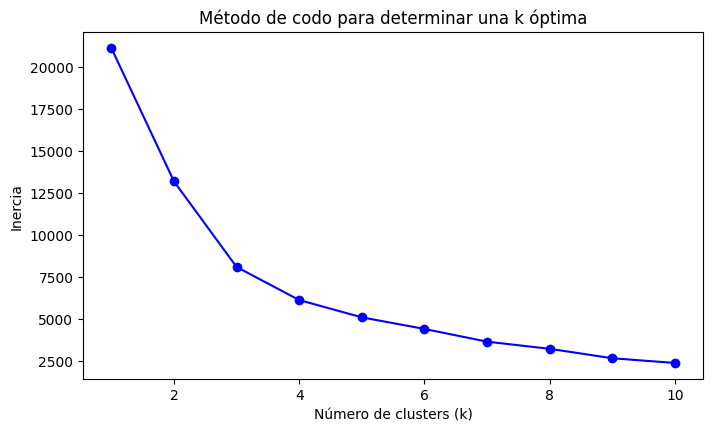

In [20]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4.5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método de codo para determinar una k óptima')
plt.show()

Ahora aplicaremos K-means con una K de 3 ya que a partir de cuatro ya se comienza a normalizar además de con una K de 20, 40, 60 y 100, verificando en todos los casos los centros de los clusters en cada uno y visualizandolos primero entre comentarios y likes y después entre comentarios y compartidos para ya al final mostrar los centros y el número de elementos por cluster

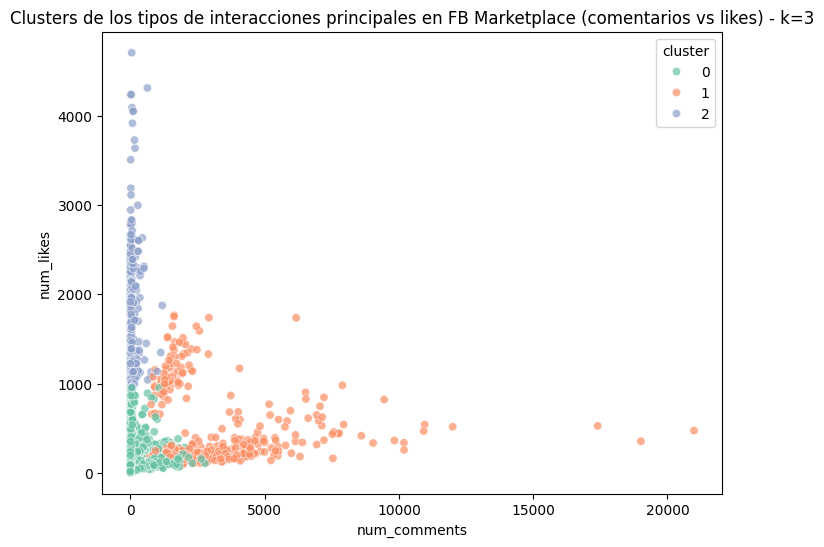

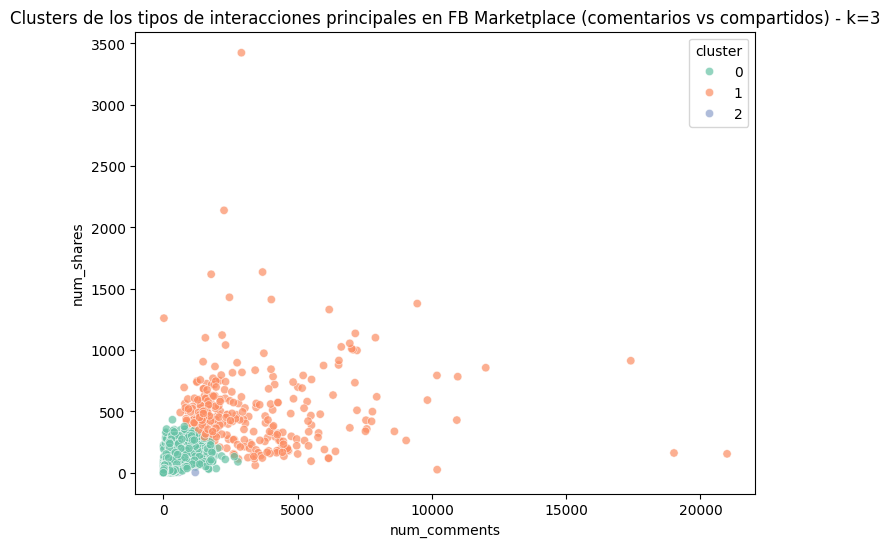

Centros de los clusters:
   num_comments  num_shares    num_likes
0     85.185604   19.009272   105.403583
1   3266.393548  502.316129   527.416129
2     71.862069   14.549072  1808.679045
Elementos por cluster
cluster
0    6363
2     377
1     310
Name: count, dtype: int64


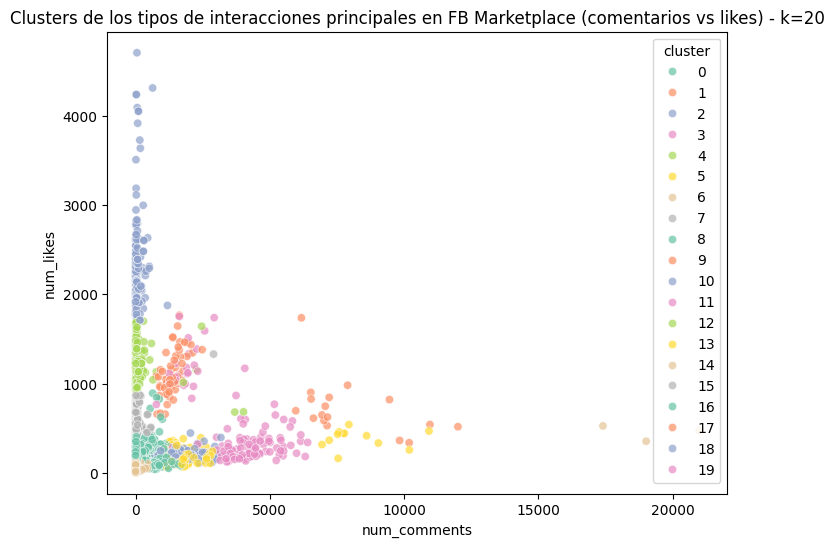

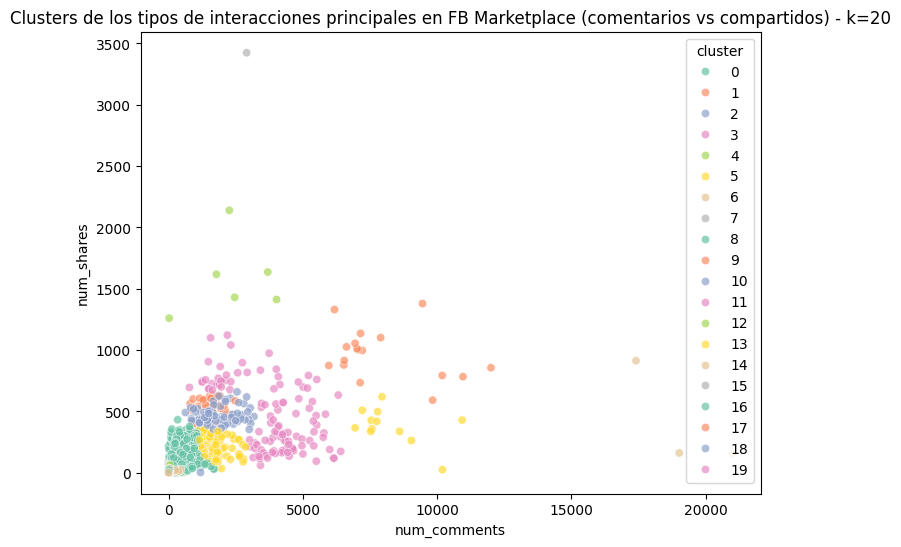

Centros de los clusters:
    num_comments   num_shares    num_likes
0      46.965625     5.670833   239.133333
1    1374.186441   480.779661  1115.881356
2      62.881081    11.789189  2186.135135
3    4609.038462   602.269231   369.076923
4      57.810000    10.300000  1228.220000
5    1616.694915   224.042373   183.745763
6   19135.666667   409.333333   450.333333
7    2903.000000  3424.000000  1330.000000
8     562.293436   229.749035   150.857143
9    6850.750000  1005.083333   810.666667
10    112.538462    37.153846  3908.615385
11   4327.949153   225.423729   279.983051
12   2370.166667  1582.500000  1115.666667
13   8252.166667   382.333333   385.583333
14      6.845755     1.321774    34.738798
15     43.274368     6.270758   580.830325
16    575.292063    96.523810   151.203175
17  10486.400000   880.600000   514.800000
18   1852.394366   465.647887   203.352113
19   1999.142857   801.857143  1048.321429
Elementos por cluster
cluster
14    4442
0      961
16     314
15     27

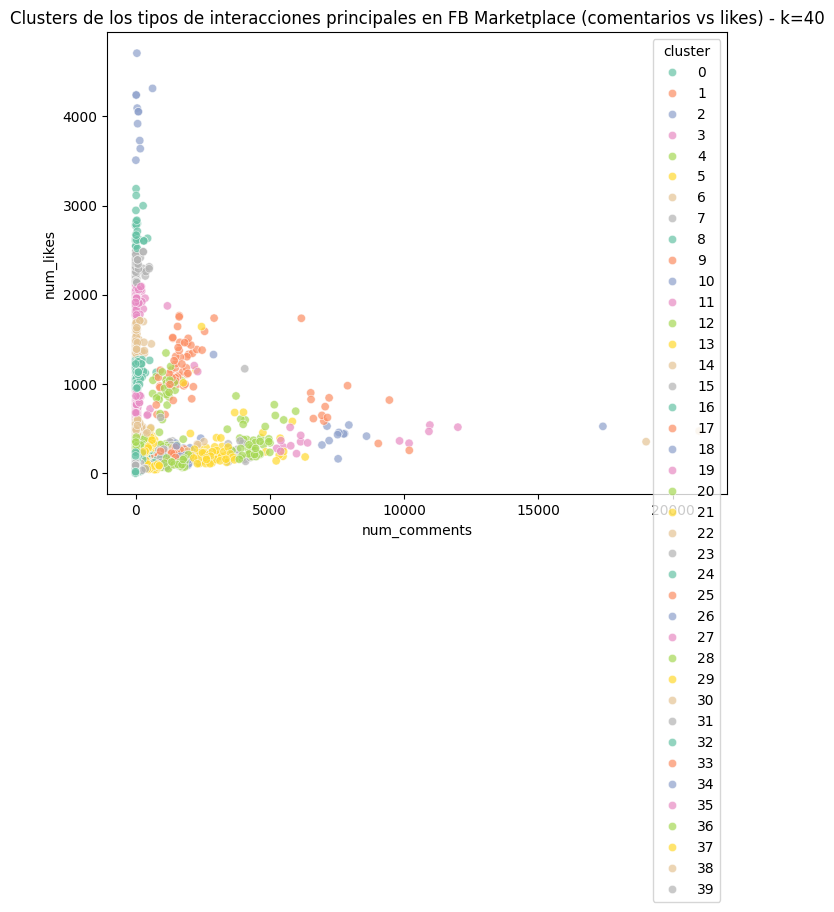

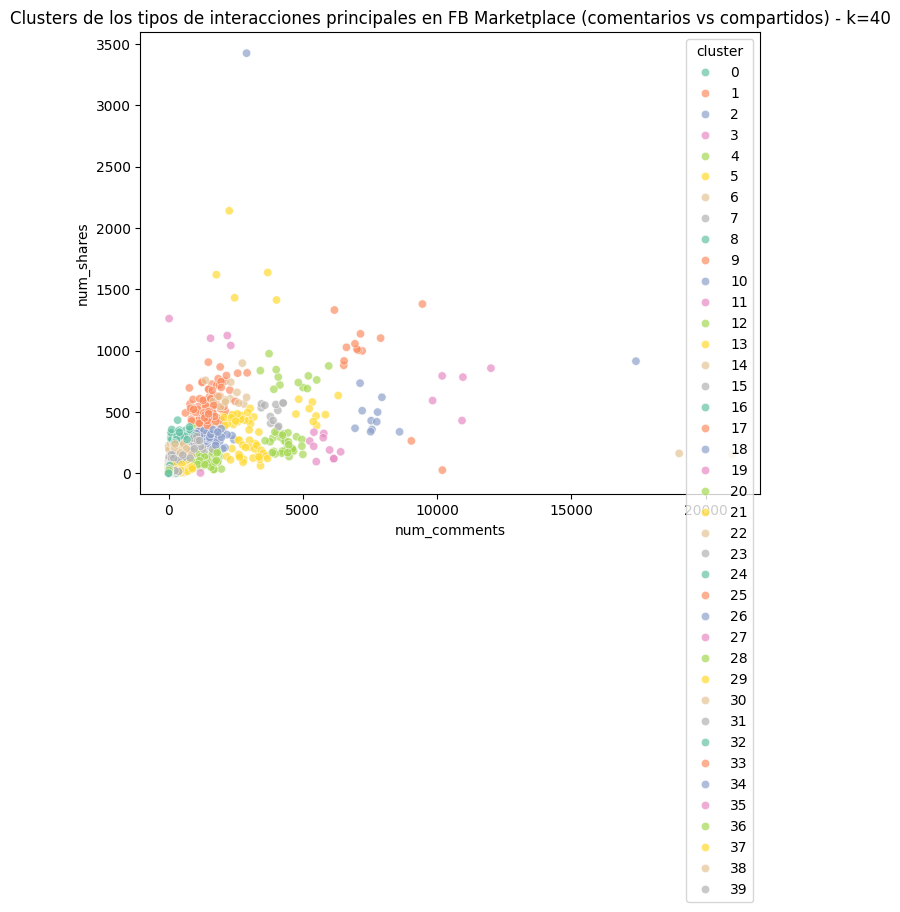

Centros de los clusters:
    num_comments   num_shares    num_likes
0      27.675258     3.869416   186.773196
1    1522.352941   559.852941  1249.852941
2    7599.700000   460.500000   409.800000
3      59.325301    12.168675  1955.807229
4    1275.592105   105.644737   195.894737
5    2840.600000  1647.000000  1034.800000
6   20001.500000   157.500000   413.000000
7    3893.166667   493.333333   309.833333
8      54.875969    10.829457  1116.093023
9    1324.150000   457.000000   214.825000
10    129.090909    43.818182  4046.090909
11   1519.500000  1130.750000  1223.250000
12   4582.666667   782.916667   588.166667
13   2634.523810   437.761905   214.476190
14     36.708995     4.550265   494.058201
15   1032.370787   225.820225   175.123596
16     72.750000    15.607143  2721.392857
17   7142.545455  1075.636364   847.727273
18   2903.000000  3424.000000  1330.000000
19  10781.200000   690.600000   444.400000
20     40.356322     5.566092   316.910920
21   2980.555556   168.185185

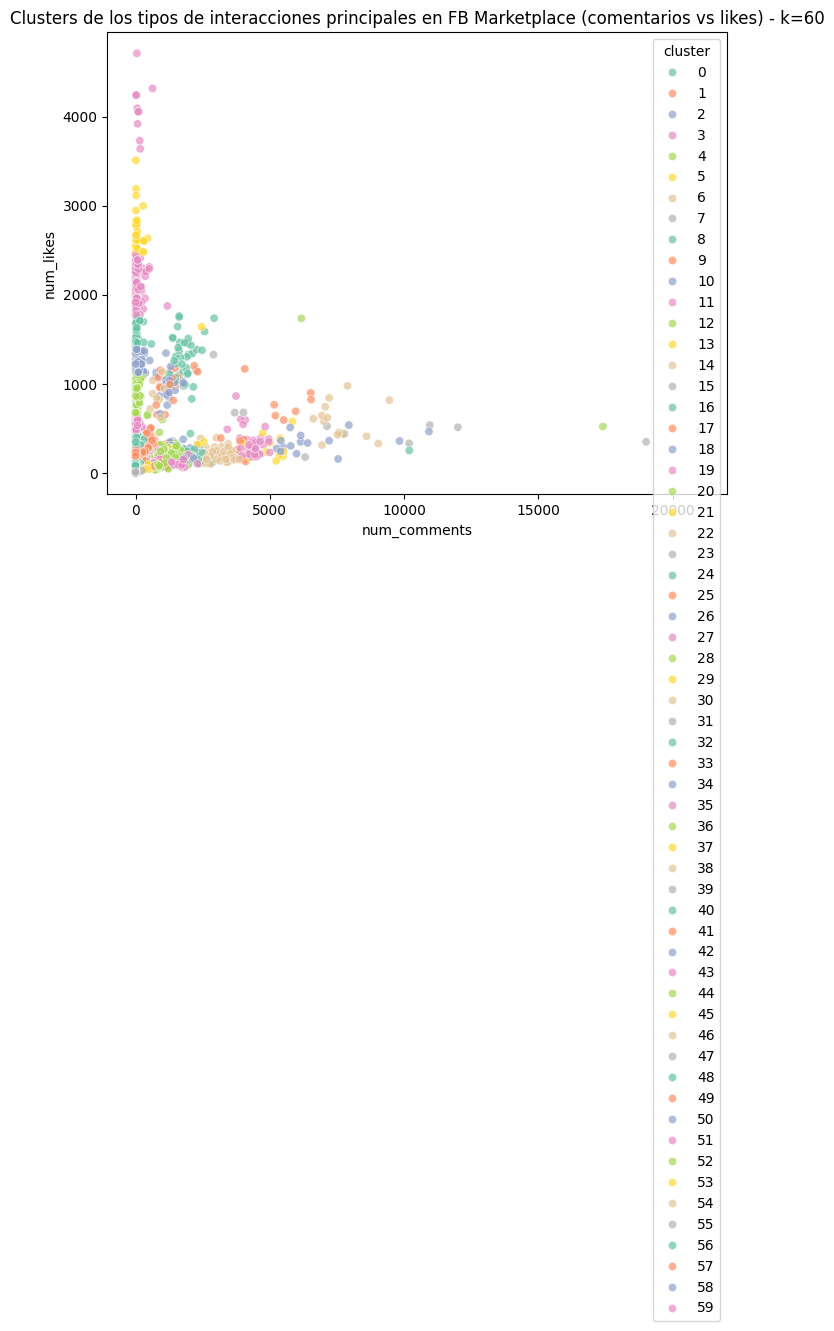

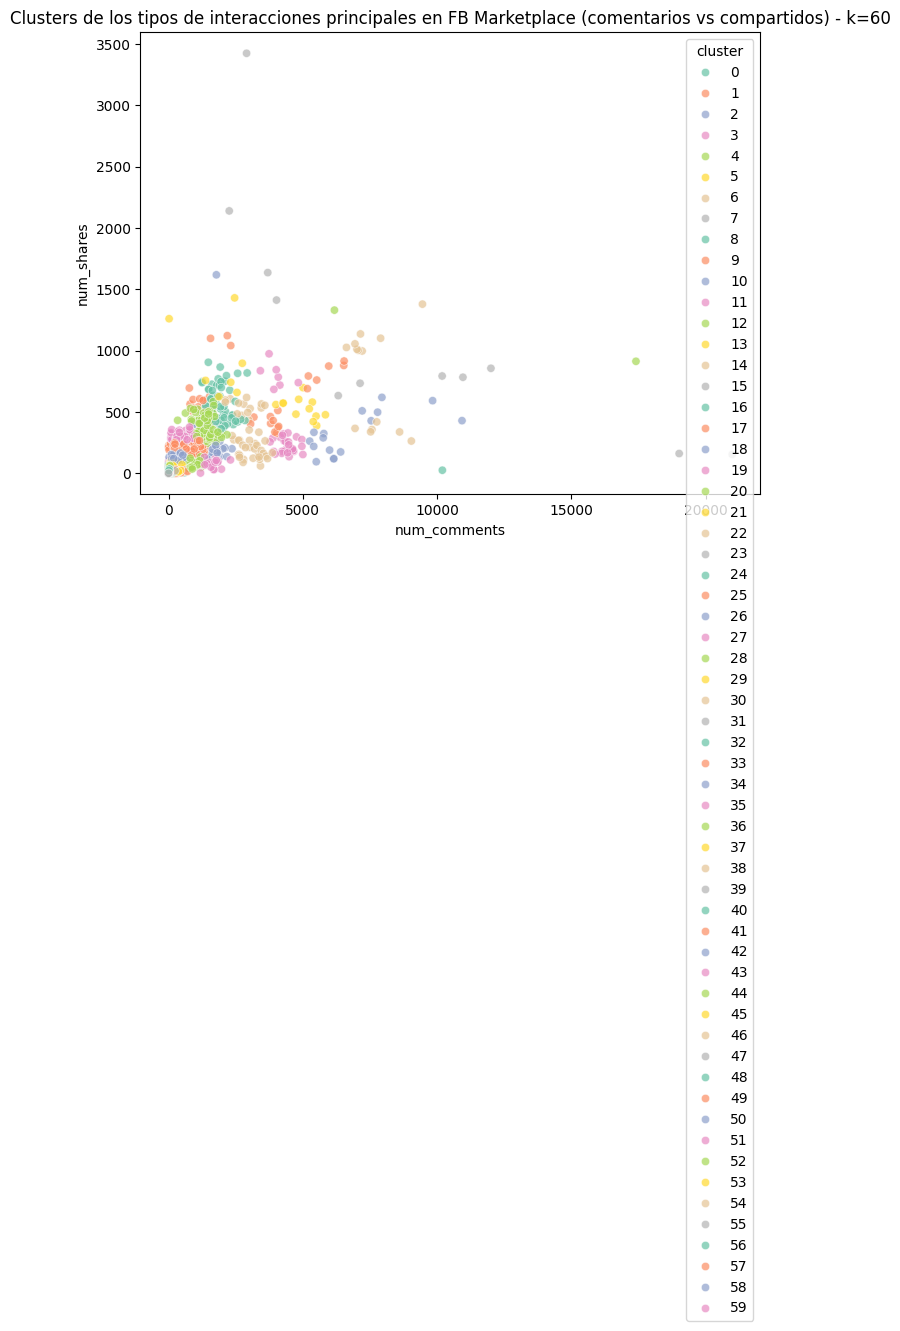

Centros de los clusters:
    num_comments   num_shares    num_likes
0      15.216632     2.290554   100.770021
1    1197.333333   559.555556   972.222222
2    7619.250000   513.500000   377.500000
3      59.225000    10.962500  1959.325000
4     911.493506    82.545455   189.506494
5    2458.000000  1430.000000  1643.000000
6    2935.307692   266.076923   243.307692
7   20001.500000   157.500000   413.000000
8      28.370107     5.167260   354.003559
9     428.772727   209.927273   129.045455
10     72.920455    12.147727  1240.022727
11    140.800000    48.200000  4099.700000
12   1435.230769   311.615385   172.307692
13   4993.916667   528.750000   291.333333
14   9452.000000  1379.000000   820.000000
15   2903.000000  3424.000000  1330.000000
16   2202.368421   431.421053   202.105263
17   5817.833333   818.500000   739.166667
18  10378.500000   510.500000   415.000000
19   4406.269231   225.576923   277.384615
20     61.333333     8.013889   754.138889
21     80.241379    13.965517

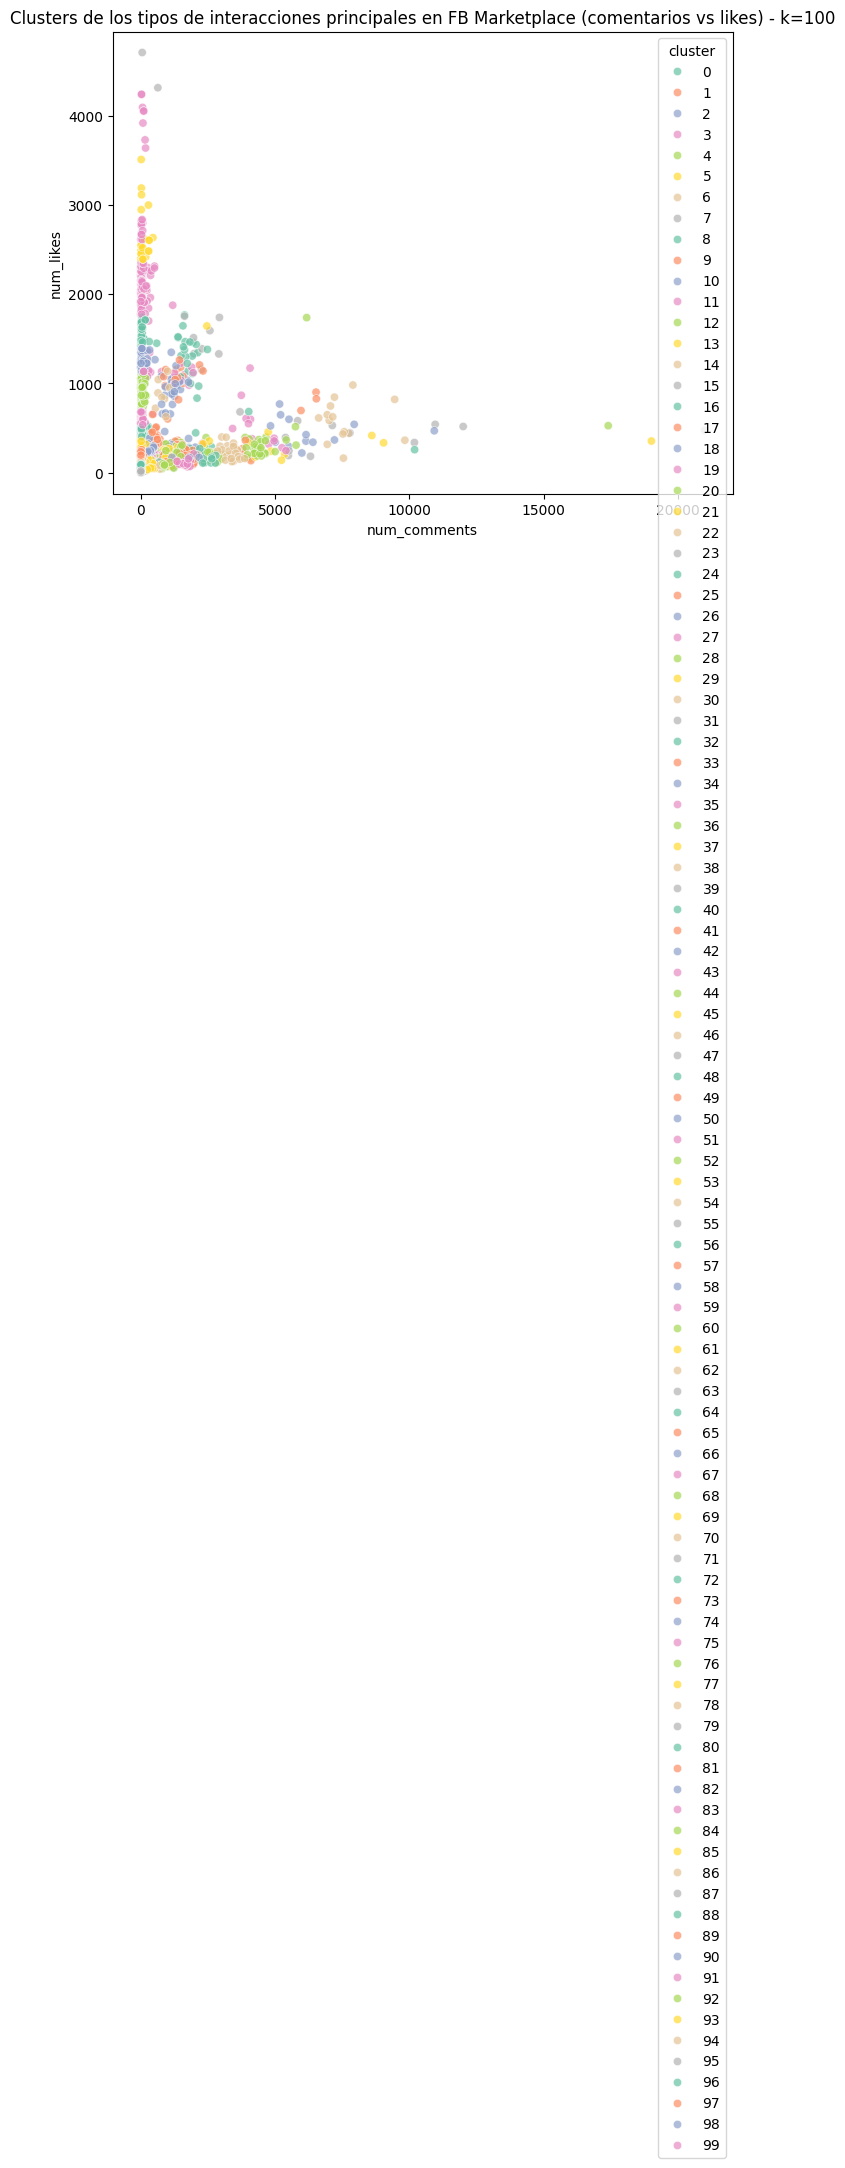

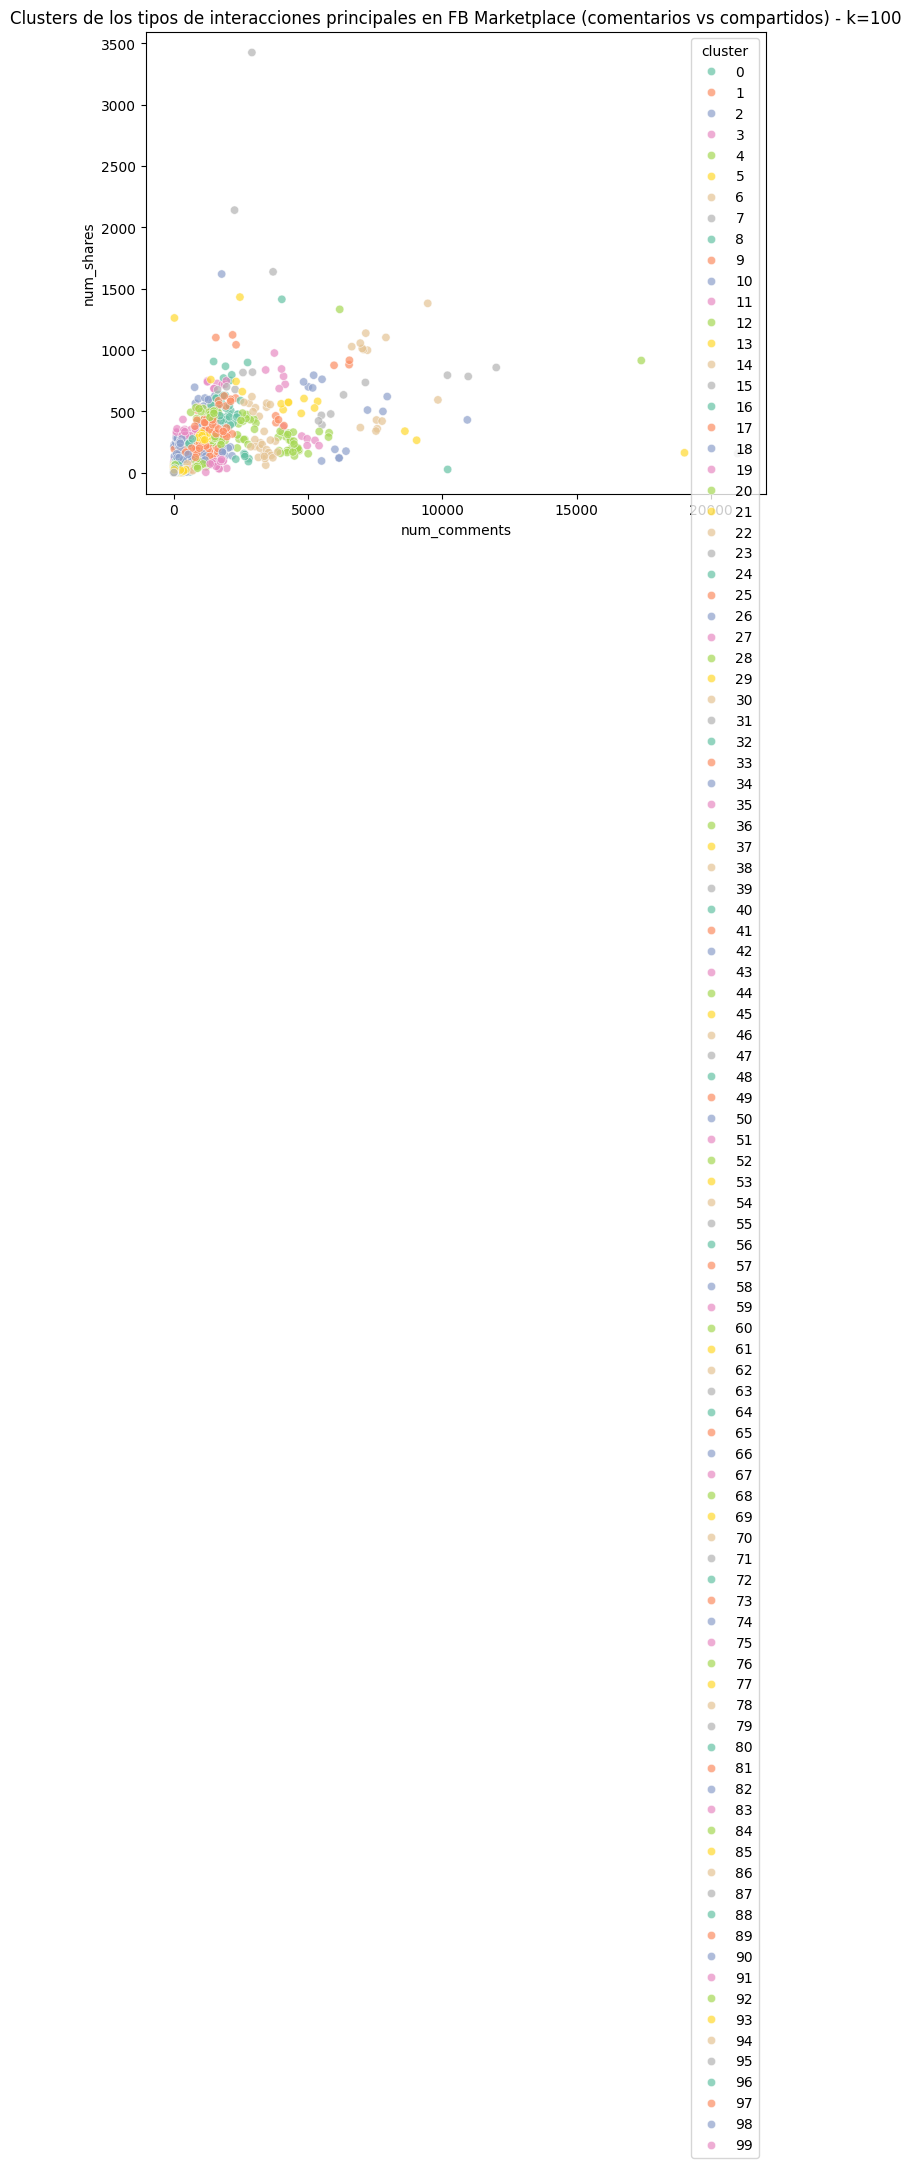

Centros de los clusters:
    num_comments  num_shares    num_likes
0       7.370370    1.900901    62.718719
1    1283.636364  509.181818  1073.636364
2    7644.666667  542.000000   449.666667
3      28.161765    4.720588  1947.705882
4     920.085106   69.425532   179.617021
..           ...         ...          ...
95   5557.500000  438.000000   351.250000
96   2744.000000  897.000000   197.000000
97   1376.117647  170.411765   221.117647
98    275.365854  237.024390   122.682927
99     25.058824    4.352941  2698.176471

[100 rows x 3 columns]
Elementos por cluster
cluster
23    3015
0     1015
62     576
41     379
93     244
      ... 
96       1
28       1
56       1
86       1
18       1
Name: count, Length: 100, dtype: int64


In [22]:
k_values = [3, 20, 40, 60, 100]

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    df_clean['cluster'] = kmeans.fit_predict(X_scaled)
    
    plt.figure(figsize=(8,6))
    sns.scatterplot(
        x='num_comments',
        y='num_likes',
        hue='cluster',
        palette='Set2',
        data=df_clean,
        alpha=0.7
    )
    plt.title(f"Clusters de los tipos de interacciones principales en FB Marketplace (comentarios vs likes) - k={k}")
    plt.show()
    
    plt.figure(figsize=(8,6))
    sns.scatterplot(
        x='num_comments',
        y='num_shares',
        hue='cluster',
        palette='Set2',
        data=df_clean,
        alpha=0.7
    )
    plt.title(f"Clusters de los tipos de interacciones principales en FB Marketplace (comentarios vs compartidos) - k={k}")
    plt.show()
    
    centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=['num_comments', 'num_shares', 'num_likes'])
    print("Centros de los clusters:")
    print(centers)
    
    print("Elementos por cluster")
    print(df_clean['cluster'].value_counts())

## Respondiendo a las preguntas...

Una vez determinado los clusters y analizando los centros puedo decir que son representativos de los datos ya que comparando comentarios vs likes y comentarios vs compartidos el cluster 0 es el grupo de publicaciones con similar engament por likes y comentarios pero en general el de menor engament, el cluster 1 es el grupo de publicaciones que tiene como principal engagement los comentarios y de manera moderada y similar un engament por compartidos y likes y el cluster 2 son aquellas publicaciones cuyo principal y mayoritario engament son los likes pero aún así poseen algo de engament por comentarios y compartidos.

En pocas palabras aquellas publicaciones con un menor pero relativamente mayor cantidad de likes frente a compartidos o comentarios tienen el menor engament en general; las publicaciones con mayor engament por comentarios tienen un engament moderado y una publicación con mayor cantidad de likes suele tener la menor cantidad de comentarios y compartidos.

Regresando al análisis, el valor de k lo obtuve observando el punto en el que ya no hubiera una diferencia considerable de inercias

Y no considero que sea representativo un valor de k más alto, como sería el caso de un valor de k de 20, 40, 60 y 100 ya que dificultaria o haría imposible el ver una relación entre las 3 formas principales de engament

Volviendo al análisis, los comentarios y likes tienen la mayor distancia del centro con respecto a los compartidos, y estos últimos llegan a tener la mayor distancia en el cluster 1 y 2 respectivamente

Y dado a que los datos tienen muchos outliers los grupos se ven muy dispersos

### Referencias:

1. GeeksforGeeks. (2025a, junio 24). Pandas.to_datetime()Python. GeeksforGeeks. https://www.geeksforgeeks.org/python/python-pandas-to_datetime/

2. W3Schools.com. (s. f.-b). https://www.w3schools.com/python/python_ml_k-means.asp

3. Introduction to k-Means Clustering with scikit-learn in Python. (2023, 10 marzo). Recuperado 30 de octubre de 2025, de https://www.datacamp.com/tutorial/k-means-clustering-python